# Notebook 03 — Dynamic Regression (Time-Varying Coefficients)

**Reference:** W&H: Introduction to Regression, Autoregression, and Related Models; The Multiple Regression DLM

**New engine:** `DLMSpecTV` dataclass, `kalman_filter_tv(F_seq, G, V, W, m0, C0, y)`

## 1. Motivation

Standard OLS regression assumes a fixed relationship between predictors and response:

$$
y_t = x_t' \beta + \varepsilon_t, \quad \varepsilon_t \sim N(0, V)
$$

In many real applications the relationship itself evolves over time: a marketing mix model where ad effectiveness shifts, a macro model where the inflation-unemployment relationship changes across regimes, or a financial beta that moves with market conditions.

**Dynamic regression** models the coefficient vector $\beta_t$ as a latent state evolving via a random walk:

$$
y_t = x_t' \beta_t + \varepsilon_t, \quad \beta_t = \beta_{t-1} + \eta_t
$$

This is a DLM with **time-varying observation matrix** $F_t = x_t'$.

## 2. As a DLM

Set $\theta_t = \beta_t$ (the coefficient vector), $F_t = x_t^\top$ (row vector of predictors at time $t$), $G = I$ (random walk), $W = $ coefficient evolution variance.

$$
\underbrace{y_t = x_t' \beta_t + \varepsilon_t}_{\text{observation, with time-varying } F_t = x_t'}
\qquad
\underbrace{\beta_t = \beta_{t-1} + \eta_t}_{\text{state, } G = I,\; W = \text{diag}(\sigma_{\beta}^2)}
$$

The standard `DLMSpec` has a **fixed** $F$. `DLMSpecTV` generalises this by storing a $(T, p, d)$ array `F_seq` of observation matrices, one per time step.

`kalman_filter_tv` is identical to `kalman_filter` except it picks `F = F_seq[t]` inside the loop.

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

from engine.filter import kalman_filter_tv
from engine.models import DLMSpecTV

## 3. Worked example: two-regime slope

Simulate a series where the relationship between a single predictor $x_t$ and the response $y_t$ reverses sign at $t = 100$.

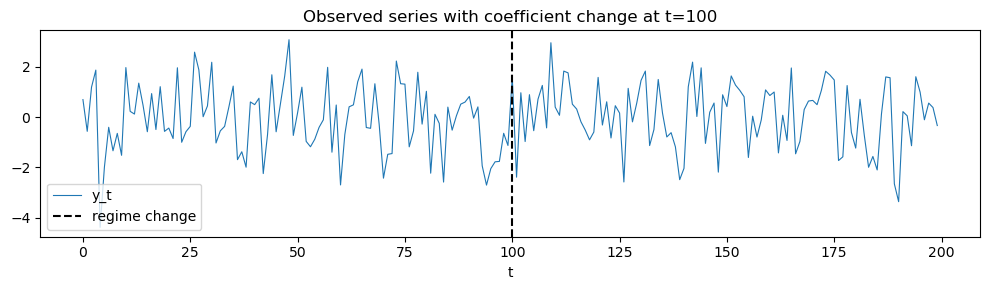

In [2]:
rng = np.random.default_rng(42)
T = 200

# Predictor: slightly trended
x = rng.normal(0, 1, T)

# True time-varying coefficient: +1.5 for t<100, -1.0 for t>=100
beta_true = np.where(np.arange(T) < 100, 1.5, -1.0)

V_true = 0.5
y = beta_true * x + rng.normal(0, np.sqrt(V_true), T)

plt.figure(figsize=(10, 3))
plt.plot(y, lw=0.8, label='y_t')
plt.axvline(100, ls='--', color='k', label='regime change')
plt.legend(); plt.xlabel('t'); plt.title('Observed series with coefficient change at t=100')
plt.tight_layout(); plt.show()

In [3]:
# Build F_seq: shape (T, 1, 1) — scalar predictor
F_seq = x.reshape(T, 1, 1)   # F_t = [[x_t]]

# State: beta_t \in R^1, evolves as a random walk
d = 1
G = np.eye(d)
V_mat = np.array([[V_true]])
W_mat = 0.1 * np.eye(d)    # small coefficient evolution variance
m0 = np.zeros(d)
C0 = 10.0 * np.eye(d)

fr = kalman_filter_tv(F_seq, G, V_mat, W_mat, m0, C0, y.reshape(T, 1))
print(f"Log marginal likelihood: {fr.loglik:.2f}")

Log marginal likelihood: -246.55


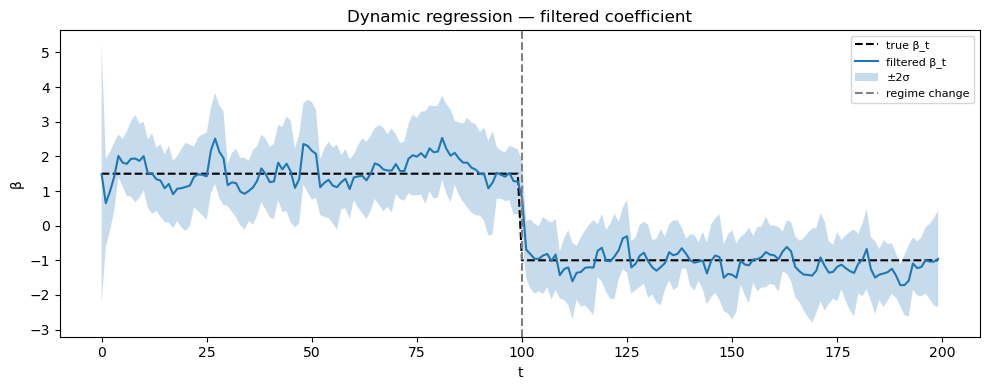

In [4]:
t = np.arange(T)
std = np.sqrt(fr.C[:, 0, 0])

plt.figure(figsize=(10, 4))
plt.plot(t, beta_true, 'k--', lw=1.5, label='true β_t')
plt.plot(t, fr.m[:, 0], 'C0', lw=1.5, label='filtered β_t')
plt.fill_between(t, fr.m[:, 0]-2*std, fr.m[:, 0]+2*std, alpha=0.25, label='±2σ')
plt.axvline(100, ls='--', color='grey', label='regime change')
plt.xlabel('t'); plt.ylabel('β'); plt.title('Dynamic regression — filtered coefficient')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Comparison with OLS

OLS estimates a single $\hat{\beta}$ over the full sample, which averages across the regime change and gives a poor estimate in each regime.

In [5]:
# Full-sample OLS
beta_ols, _, _, _ = lstsq(x.reshape(-1, 1), y, rcond=None)
print(f"OLS β̂ (full sample): {beta_ols[0]:.3f}")
print(f"True β: +1.5 (t<100) → -1.0 (t≥100)")
print(f"Dynamic filter β̂ at t=50: {fr.m[50, 0]:.3f}  (true: 1.5)")
print(f"Dynamic filter β̂ at t=180: {fr.m[180, 0]:.3f}  (true: -1.0)")

OLS β̂ (full sample): -0.090
True β: +1.5 (t<100) → -1.0 (t≥100)
Dynamic filter β̂ at t=50: 2.163  (true: 1.5)
Dynamic filter β̂ at t=180: -1.099  (true: -1.0)


## 5. Two-predictor extension

In [6]:
# Generate a two-predictor scenario
x1 = rng.normal(0, 1, T)
x2 = rng.normal(0, 1, T)
beta1_true = np.where(np.arange(T) < 100, 2.0, 0.5)
beta2_true = 0.8  # stable second predictor

y2 = beta1_true * x1 + beta2_true * x2 + rng.normal(0, np.sqrt(V_true), T)

# F_seq: shape (T, 1, 2)
F_seq2 = np.stack([x1, x2], axis=1).reshape(T, 1, 2)
d2 = 2
G2 = np.eye(d2)
W2 = 0.05 * np.eye(d2)
m0_2 = np.zeros(d2)
C0_2 = 10.0 * np.eye(d2)

fr2 = kalman_filter_tv(F_seq2, G2, V_mat, W2, m0_2, C0_2, y2.reshape(T, 1))
print(f"Two-predictor log-lik: {fr2.loglik:.2f}")

Two-predictor log-lik: -262.06


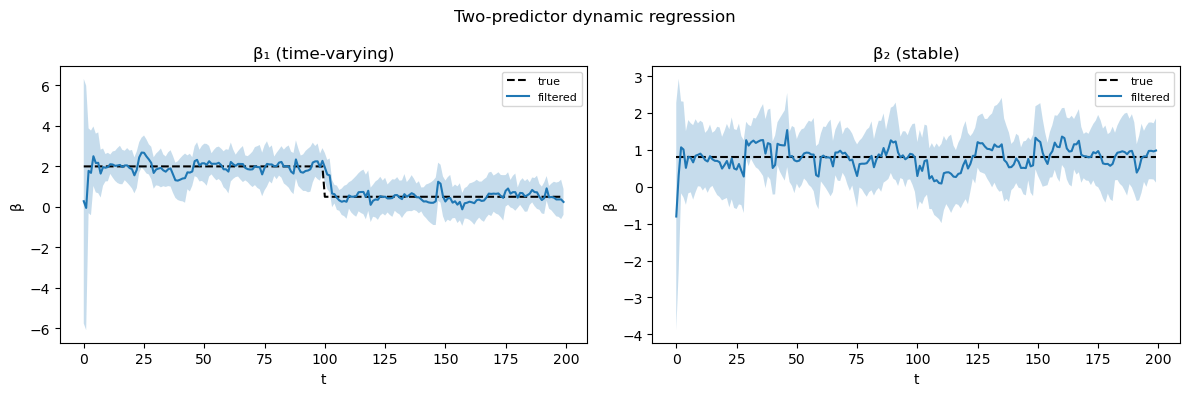

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, j, beta_true_j, name in [
    (ax1, 0, beta1_true, 'β₁ (time-varying)'),
    (ax2, 1, np.full(T, beta2_true), 'β₂ (stable)'),
]:
    std_j = np.sqrt(fr2.C[:, j, j])
    ax.plot(t, beta_true_j, 'k--', lw=1.5, label='true')
    ax.plot(t, fr2.m[:, j], 'C0', lw=1.5, label='filtered')
    ax.fill_between(t, fr2.m[:, j]-2*std_j, fr2.m[:, j]+2*std_j, alpha=0.25)
    ax.set(title=name, xlabel='t', ylabel='β')
    ax.legend(fontsize=8)
plt.suptitle('Two-predictor dynamic regression')
plt.tight_layout(); plt.show()

## 6. Exercises

**Exercise 1.** Increase `W_mat` from `0.1*I` to `0.5*I` in the single-predictor example. How does this affect how quickly the filter tracks the regime change? What is the trade-off?

In [8]:
# YOUR CODE HERE


**Exercise 2.** Use `compare_models` from `engine.comparison` to compare the dynamic-regression model against a static DLM (standard `DLMSpec` with $F = $ column of ones, i.e. an intercept-only model). Which has higher log marginal likelihood on the two-regime data?

In [9]:
# YOUR CODE HERE
# Hint: compare_models works with DLMSpec, not DLMSpecTV.
# Run kalman_filter_tv manually and use log_bayes_factor from engine.comparison.
from engine.comparison import log_bayes_factor
from engine.models import make_local_level


**Exercise 3.** Implement a **discount factor version** of the dynamic regression: instead of specifying `W_mat`, use `G @ C_prev @ G.T / delta` for the predict step. Wrap this as a function and compare its log-likelihood to the fixed-W version across `delta \in [0.8, 1.0]`.

In [10]:
# YOUR CODE HERE
